In [44]:
import numpy as np
import matplotlib.pyplot as plt
import csv
from pathlib import Path
import mcstasscript as ms
from scipy.optimize import curve_fit  

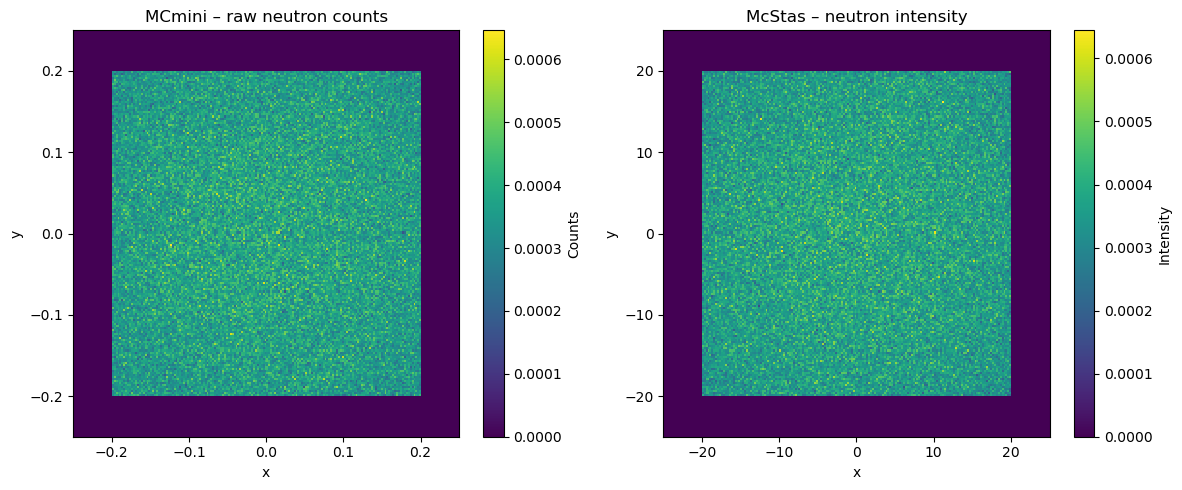

In [ ]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

# ---------- MCmini data ----------
flat_hits_path = Path("/Users/christian/Documents/Study/bachelor_project/mcmini/flat_hits_binned_srcsimple_count.csv")

binned_data = np.loadtxt(flat_hits_path, delimiter=',', comments='#')
col_counts = binned_data[:, 2]
H_mini = col_counts.reshape((200, 200))

x_edges = np.linspace(-0.25, 0.25, 201)
y_edges = np.linspace(-0.25, 0.25, 201)

extent_mini = [x_edges[0], x_edges[-1], y_edges[0], y_edges[-1]]

# ---------- McStas data ----------
sphere_mon = ms.load_data(
    "/Users/christian/Documents/Study/bachelor_project/mcmini_verification/source_simple_verification/flat_monitor"
)[0]

meta = sphere_mon.metadata
hits = sphere_mon.Intensity
xmin, xmax, ymin, ymax = meta.limits
extent_mc = [xmin, xmax, ymin, ymax]

Hmc = hits

# ---------- Plot side-by-side ----------
fig, axs = plt.subplots(1, 2, figsize=(12,5))

im0 = axs[0].imshow(
    H_mini.T,
    origin="lower",
    extent=extent_mini,
    cmap="viridis",
    interpolation="nearest",
    aspect="auto"
)
axs[0].set_title("MCmini – raw neutron counts")
axs[0].set_xlabel("x")
axs[0].set_ylabel("y")
fig.colorbar(im0, ax=axs[0], label="Counts")

im1 = axs[1].imshow(
    Hmc.T,
    origin="lower",
    extent=extent_mc,
    cmap="viridis",
    interpolation="nearest",
    aspect="auto"
)
axs[1].set_title("McStas – neutron intensity")
axs[1].set_xlabel("x")
axs[1].set_ylabel("y")
fig.colorbar(im1, ax=axs[1], label="Intensity")

plt.tight_layout()
plt.show()

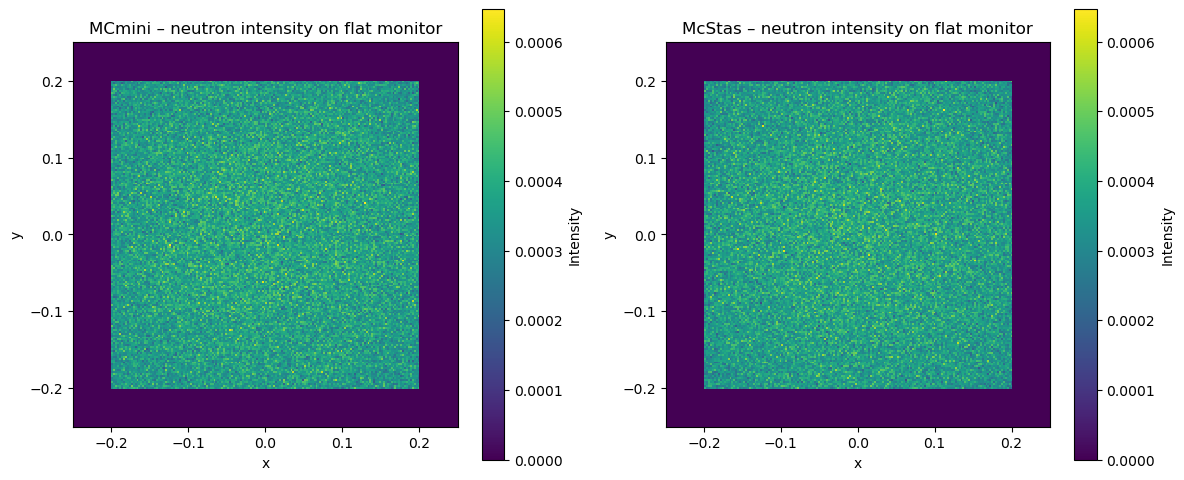

In [46]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

# ---------- MCmini data ----------
flat_hits_path = Path("/Users/christian/Documents/Study/bachelor_project/mcmini/flat_hits_binned_srcsimple.csv")

binned_data = np.loadtxt(flat_hits_path, delimiter=',', comments='#')
col_counts = binned_data[:, 2]
H_mini = col_counts.reshape((200, 200))

x_edges = np.linspace(-0.25, 0.25, 201)
y_edges = np.linspace(-0.25, 0.25, 201)

extent_mini = [x_edges[0], x_edges[-1], y_edges[0], y_edges[-1]]

# ---------- McStas data ----------
sphere_mon = ms.load_data(
    "/Users/christian/Documents/Study/bachelor_project/mcmini_verification/source_simple_verification/flat_monitor"
)[0]

meta = sphere_mon.metadata
hits = sphere_mon.Intensity
xmin, xmax, ymin, ymax = meta.limits
extent_mc = [xmin, xmax, ymin, ymax]
extent_mc_m = [xmin/100, xmax/100, ymin/100, ymax/100]

Hmc = hits

# ---------- Plot side-by-side ----------
fig, axs = plt.subplots(1, 2, figsize=(12,5))
vmin = min(H_mini.min(), Hmc.min())
vmax = max(H_mini.max(), Hmc.max())

im0 = axs[0].imshow(
    H_mini.T,
    origin="lower",
    extent=extent_mini,
    cmap="viridis",
    interpolation="nearest",
    vmin=vmin,
    vmax=vmax
)
axs[0].set_title("MCmini – neutron intensity on flat monitor")
axs[0].set_xlabel("x")
axs[0].set_ylabel("y")
fig.colorbar(im0, ax=axs[0], label="Intensity")

im1 = axs[1].imshow(
    Hmc.T,
    origin="lower",
    extent=extent_mc_m,
    cmap="viridis",
    interpolation="nearest",
    vmin=vmin,
    vmax=vmax
)
axs[1].set_title("McStas – neutron intensity on flat monitor")
axs[1].set_xlabel("x")
axs[1].set_ylabel("y")
fig.colorbar(im1, ax=axs[1], label="Intensity")

plt.tight_layout()
plt.show()




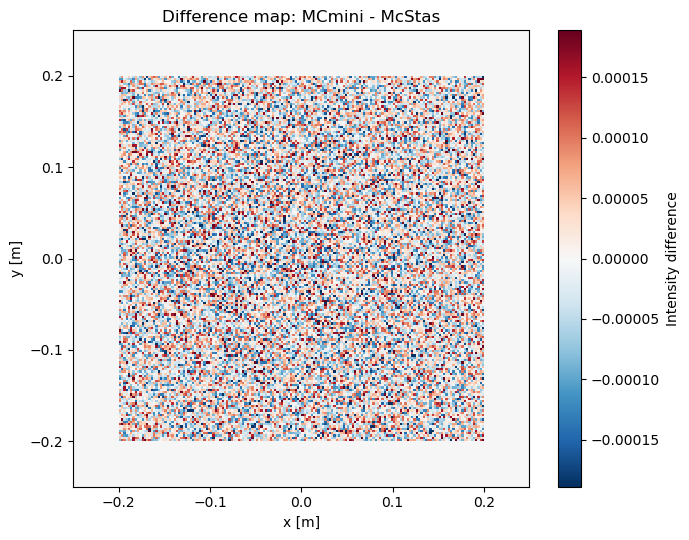

Mean bias (MCmini-McStas): -8.797445e-09
MAE:                        4.293751e-05
RMSE:                       6.732918e-05
Relative L2 error:          2.247661e-01


In [49]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

# ---------- MCmini data ----------
flat_hits_path = Path("/Users/christian/Documents/Study/bachelor_project/mcmini/flat_hits_binned_srcsimple.csv")
binned_data = np.loadtxt(flat_hits_path, delimiter=",", comments="#")
H_mini = binned_data[:, 2].reshape((200, 200))

# ---------- McStas data ----------
sphere_mon = ms.load_data(
    "/Users/christian/Documents/Study/bachelor_project/mcmini_verification/source_simple_verification/flat_monitor"
)[0]
meta = sphere_mon.metadata
Hmc = sphere_mon.Intensity
if Hmc.shape != H_mini.shape:
    Hmc = Hmc.T

# McStas metadata is in cm for PSD_monitor, convert to meters for consistent axes
xmin, xmax, ymin, ymax = meta.limits
extent_m = [xmin / 100.0, xmax / 100.0, ymin / 100.0, ymax / 100.0]

# ---------- Difference ----------
D = H_mini - Hmc
vabs = np.max(np.abs(D))/2

fig, ax = plt.subplots(1, 1, figsize=(7, 5.5))
im = ax.imshow(
    D.T,
    origin="lower",
    extent=extent_m,
    cmap="RdBu_r",
    vmin=-vabs,
    vmax=vabs,
    interpolation="nearest",
)
ax.set_title("Difference map: MCmini - McStas")
ax.set_xlabel("x [m]")
ax.set_ylabel("y [m]")
fig.colorbar(im, ax=ax, label="Intensity difference")
plt.tight_layout()
plt.show()

# ---------- Summary metrics ----------
mae = np.mean(np.abs(D))
rmse = np.sqrt(np.mean(D**2))
mean_bias = np.mean(D)
rel_l2 = np.linalg.norm(D.ravel()) / max(np.linalg.norm(Hmc.ravel()), 1e-20)

print(f"Mean bias (MCmini-McStas): {mean_bias:.6e}")
print(f"MAE:                        {mae:.6e}")
print(f"RMSE:                       {rmse:.6e}")
print(f"Relative L2 error:          {rel_l2:.6e}")



## wavelength comparison

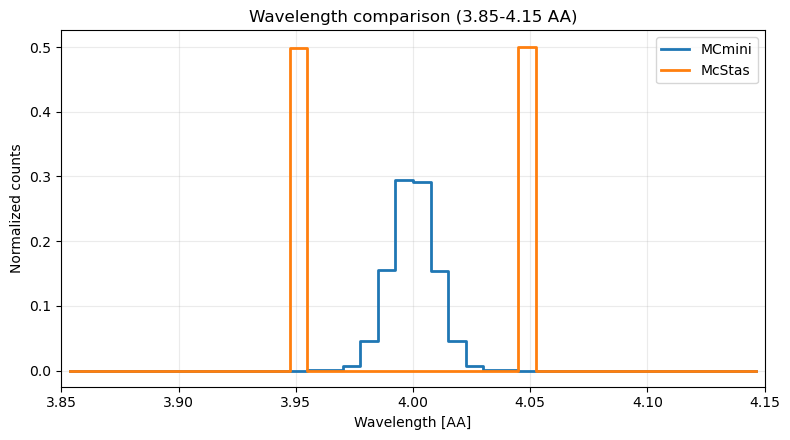

In [48]:
# NEW CELL: wavelength comparison (MCmini vs McStas), 3.85-4.15 AA
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

mcmini_path = Path("/Users/christian/Documents/Study/bachelor_project/mcmini/flat_hits_binned_srcsimple.csv")
mcstas_l_path = Path("/Users/christian/Documents/Study/bachelor_project/mcmini_verification/source_simple_verification/flat_monitor/wavelength.dat")

lmin, lmax = 3.85, 4.15
bins = np.linspace(lmin, lmax, 41)
centers = 0.5 * (bins[:-1] + bins[1:])

# MCmini (weighted by intensity per pixel)
b = np.loadtxt(mcmini_path, delimiter=",", comments="#")
if b.shape[1] < 5:
    raise RuntimeError("MCmini file needs columns I,L,lambda_mean. Re-run mcmini after wavelength patch.")
I_mini = b[:, 2]
lam_mini = b[:, 4]
mask = I_mini > 0
h_mini, _ = np.histogram(lam_mini[mask], bins=bins, weights=I_mini[mask])

# McStas (L_monitor bins)
wl = np.loadtxt(mcstas_l_path, comments="#")
lam_mc = wl[:, 0]
I_mc = wl[:, 1]
sel = (lam_mc >= lmin) & (lam_mc <= lmax)
h_mc, _ = np.histogram(lam_mc[sel], bins=bins, weights=I_mc[sel])

# Normalize for shape comparison
if h_mini.sum() > 0:
    h_mini = h_mini / h_mini.sum()
if h_mc.sum() > 0:
    h_mc = h_mc / h_mc.sum()

plt.figure(figsize=(8, 4.5))
plt.step(centers, h_mini, where="mid", lw=2, label="MCmini")
plt.step(centers, h_mc, where="mid", lw=2, label="McStas")
plt.xlim(lmin, lmax)
plt.xlabel("Wavelength [AA]")
plt.ylabel("Normalized counts")
plt.title("Wavelength comparison (3.85-4.15 AA)")
plt.grid(alpha=0.25)
plt.legend()
plt.tight_layout()
plt.show()



# 4PI monitor verification with simple source

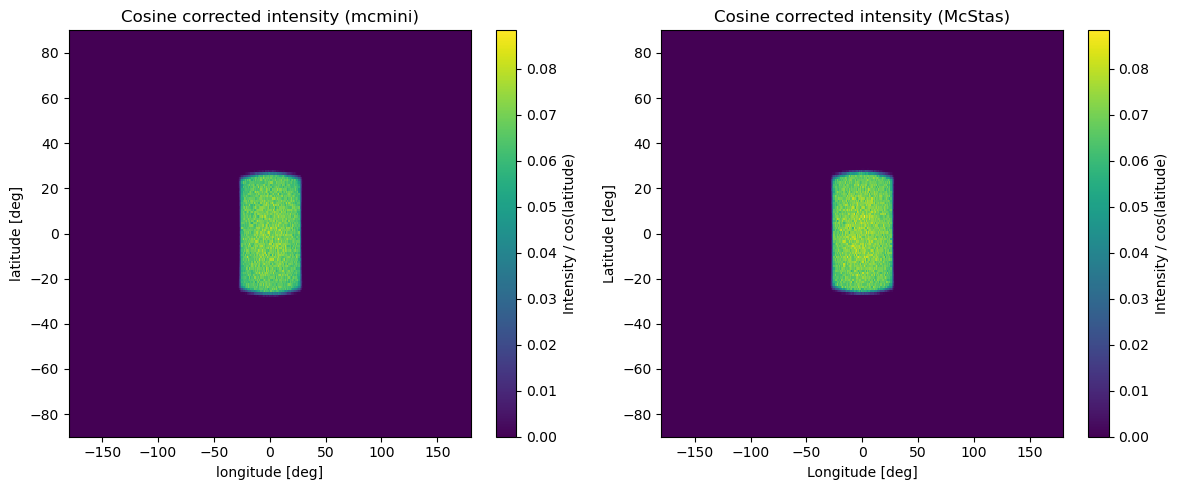

Total intensity (mcmini) = 184.7885727652832
Total intensity (McStas) = 184.78857276528322
Highest latitude bin with nonzero counts: 27.5 degrees
Highest longitude bin with nonzero counts: 28.5 degrees
Highest latitude bin with nonzero counts (McStas): 28.5 degrees
Highest longitude bin with nonzero counts (McStas): 28.5 degrees
RMSE between cosine-corrected maps: 1.403116e-03


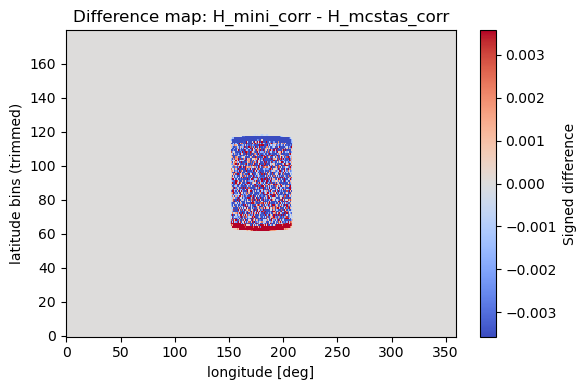

In [16]:
#mcmini data 
mcmini_binned_path = Path("/Users/christian/Documents/Study/bachelor_project/mcmini/4PI_srcsimple.csv")
if not mcmini_binned_path.is_file():
    raise FileNotFoundError(f"Expected hit file at {mcmini_binned_path}")
nx, ny = 360, 180
north_pole_index, south_pole_index = -90, 90
binned_data = np.loadtxt(mcmini_binned_path, delimiter=',', comments='#')
col_counts = binned_data[:, 2]
H_mini = col_counts.reshape((ny, nx))  # (latitude bins, longitude bins)

# mcstas data 
sphere_mon = ms.load_data("/Users/christian/Documents/Study/bachelor_project/mcmini_verification/monitor_sphere_validation/4pi_srcsimple")[0]  # adjust index if needed
meta = sphere_mon.metadata
hits = sphere_mon.Intensity
xmin, xmax, ymin, ymax = meta.limits
extent = [xmin, xmax, ymin, ymax]
Hmc = hits
if Hmc.shape == (meta.dimension[0], meta.dimension[1]):
    Hmc = Hmc.T

# cosine correction map
extent = [-180, 180, north_pole_index, south_pole_index]
latitude = np.linspace(-89.5, 89.5, 180)  # bin centers
cos_correction = np.cos(np.radians(latitude))[:, np.newaxis]  # shape (180, 1), will broadcast to (180, 360)
fig, axs = plt.subplots(1, 2, figsize=(12, 5))
# apply cosine correction to mcmini data
H_mini_corr = H_mini / np.where(cos_correction == 0, np.nan, cos_correction)  # avoid divide by zero
Hmc_corr = Hmc / np.where(cos_correction == 0, np.nan, cos_correction)  # apply same correction to McStas data
H_mini_corr = H_mini_corr[0:180, :]  # trim to -85 to 85 latitude to avoid extreme corrections at poles
H_mini_corr = H_mini_corr / np.nansum(H_mini_corr) * np.nansum(Hmc)  # scale to same total as McStas for fair comparison
Hmc_corr = Hmc_corr[0:180, :]  # trim to -85 to 85 latitude

vmin = min(np.nanmin(H_mini_corr), np.nanmin(Hmc_corr)) 
vmax = max(np.nanmax(H_mini_corr), np.nanmax(Hmc_corr)) 
axs[0].imshow(H_mini_corr, origin="lower", extent=extent, interpolation="nearest", aspect="auto", vmin=vmin, vmax=vmax)
axs[0].set_xlabel("longitude [deg]")
axs[0].set_ylabel("latitude [deg]")
axs[0].set_title("Cosine corrected intensity (mcmini)")
fig.colorbar(axs[0].images[0], ax=axs[0], label="Intensity / cos(latitude)")
axs[1].imshow(Hmc_corr, origin="lower", extent=extent, interpolation="nearest", aspect="auto", vmin=vmin, vmax=vmax)
axs[1].set_xlabel(meta.xlabel if hasattr(meta, "xlabel") else "phi [deg]")
axs[1].set_ylabel(meta.ylabel if hasattr(meta, "ylabel") else "theta [deg]")
axs[1].set_title("Cosine corrected intensity (McStas)")
fig.colorbar(axs[1].images[0], ax=axs[1], label="Intensity / cos(latitude)")
plt.tight_layout()
plt.show()

print("Total intensity (mcmini) =", H_mini_corr.sum())
print("Total intensity (McStas) =", Hmc.sum())
# find highest angle where ny and nx bin have nonzero counts
sum_over_longitude = np.nansum(H_mini_corr, axis=1)
nonzero_latitudes = np.where(sum_over_longitude > 0)[0]
if len(nonzero_latitudes) > 0:
    max_latitude_index = nonzero_latitudes[-1]
    max_latitude = latitude[max_latitude_index]
    print(f"Highest latitude bin with nonzero counts: {max_latitude:.1f} degrees")
sum_over_latitude = np.nansum(H_mini_corr, axis=0)
nonzero_longitudes = np.where(sum_over_latitude > 0)[0]
if len(nonzero_longitudes) > 0:
    max_longitude_index = nonzero_longitudes[-1]
    longitude = np.linspace(-179.5, 179.5, 360)  # bin centers
    max_longitude = longitude[max_longitude_index]
    print(f"Highest longitude bin with nonzero counts: {max_longitude:.1f} degrees")
sum_over_longitude_mc = np.nansum(Hmc_corr, axis=1)
nonzero_latitudes_mc = np.where(sum_over_longitude_mc > 0)[0]
if len(nonzero_latitudes_mc) > 0:
    max_latitude_index_mc = nonzero_latitudes_mc[-1]
    max_latitude_mc = latitude[max_latitude_index_mc]
    print(f"Highest latitude bin with nonzero counts (McStas): {max_latitude_mc:.1f} degrees")
sum_over_latitude_mc = np.nansum(Hmc_corr, axis=0)
nonzero_longitudes_mc = np.where(sum_over_latitude_mc > 0)[0]
if len(nonzero_longitudes_mc) > 0:
    max_longitude_index_mc = nonzero_longitudes_mc[-1]
    longitude = np.linspace(-179.5, 179.5, 360)  # bin centers
    max_longitude_mc = longitude[max_longitude_index_mc]
    print(f"Highest longitude bin with nonzero counts (McStas): {max_longitude_mc:.1f} degrees")

difference = H_mini_corr - Hmc_corr
rmse = np.sqrt(np.nanmean(difference**2))
print(f"RMSE between cosine-corrected maps: {rmse:.6e}")
plt.figure(figsize=(6, 4))
mx = np.nanmax(np.abs(difference))/8
plt.imshow(difference, origin="lower", interpolation="nearest", aspect="auto",
           cmap="coolwarm", vmin=-mx, vmax=mx)
plt.xlabel("longitude [deg]")
plt.ylabel("latitude bins (trimmed)")
plt.title("Difference map: H_mini_corr - H_mcstas_corr")
plt.colorbar(label="Signed difference")
plt.tight_layout()
plt.show()